# Import Libraries & Set Device

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Dataset Loading

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Train samples: 50000
Test samples: 10000


# Visualize One Sample

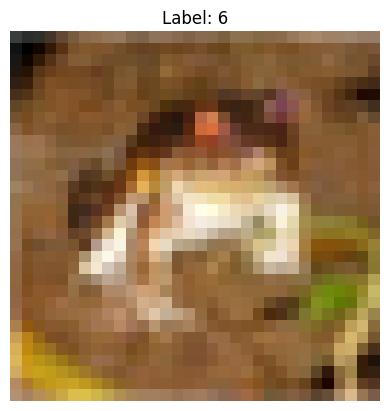

In [4]:
image, label = train_dataset[0]
image = image.permute(1, 2, 0)     # CHW → HWC
image = image * 0.5 + 0.5          # Unnormalize

plt.imshow(image)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


# DataLoader

In [5]:
batch_size = 64   # safe for laptop GPU

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# Baseline CNN Architecture

In [6]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


# Initialize Model, Loss & Optimizer

In [7]:
model = BaselineCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Train Baseline CNN

In [8]:
num_epochs = 15
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")


Epoch [1/15] Loss: 1.3609
Epoch [2/15] Loss: 0.9452
Epoch [3/15] Loss: 0.7576
Epoch [4/15] Loss: 0.6330
Epoch [5/15] Loss: 0.5213
Epoch [6/15] Loss: 0.4273
Epoch [7/15] Loss: 0.3396
Epoch [8/15] Loss: 0.2684
Epoch [9/15] Loss: 0.2079
Epoch [10/15] Loss: 0.1599
Epoch [11/15] Loss: 0.1301
Epoch [12/15] Loss: 0.1164
Epoch [13/15] Loss: 0.1029
Epoch [14/15] Loss: 0.0926
Epoch [15/15] Loss: 0.0910


# Evaluate Accuracy

In [10]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs,1)
        total +=labels.size(0)
        correct += (predicted == labels).sum().item()
        
accuracy = 100 * correct/total
print(f"Baseline CNN Accuracy (Clean): {accuracy:.2f}%")

Baseline CNN Accuracy (Clean): 74.79%


# Plot Training Loss

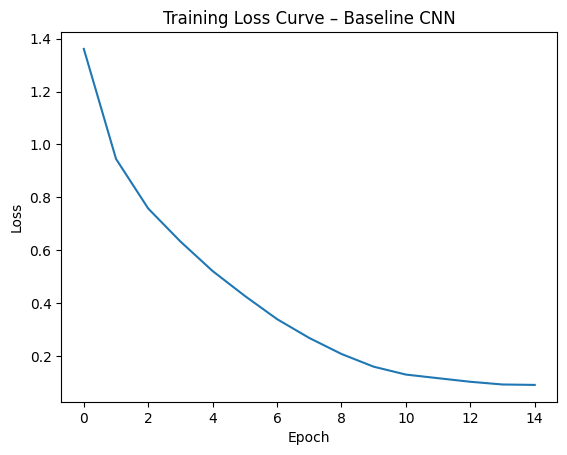

In [11]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve – Baseline CNN")
plt.show()


# Save Model

In [12]:
torch.save(model.state_dict(), "baseline_cnn_cifar10.pth")
print("Baseline CNN model saved.")


Baseline CNN model saved.
